In [39]:
#imports
from sklearn.datasets import fetch_openml
from brian2 import *
import brian2
from tqdm import tqdm

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'

from constants import *
from equations import *
from network import *
from utils import *

In [2]:
# brian2.clear_cache('cython')

In [3]:
#download mnist data
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.to_numpy()

In [4]:
#spliting into train and test sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [5]:
#net, spike_monitor, inp_group = build_network_train()

In [16]:
# 1. Prepare the Timed Array Data
num_examples = 10000
blocks_per_image = 5  # 5 blocks * 50ms = 250ms presentation
blocks_per_rest = 2   # 2 blocks * 50ms = 100ms resting
total_blocks = blocks_per_image + blocks_per_rest  # 7 blocks total (350ms)

# Create a massive 2D array: (Total Time Blocks, Number of Neurons)
rates_array = np.zeros((num_examples * total_blocks, n_input))

for i in range(num_examples):
    # Scale pixels to firing rates
    img_rates = X_train[i] / 4.0 
    
    # Fill the 5 presentation blocks for this image
    start_idx = i * total_blocks
    rates_array[start_idx : start_idx + blocks_per_image, :] = img_rates
    # The next 2 blocks remain 0.0 automatically for the resting phase!

# 2. Create the TimedArray object
input_rates = TimedArray(rates_array * Hz, dt=50*ms)

In [19]:
# Pass the TimedArray into the network builder
net, spike_monitor, inp_group = build_network_train(input_rates)

print("Starting simulation...")
# Run the entire simulation in one shot! 
# report='text' will print a progress bar so you know it's working.
net.run(num_examples * 350 * ms, report='text', report_period=120*second)

Network built successfully!
Starting simulation...
Starting simulation at t=0. s for a duration of 3.5 ks
114.3024 s (3%) simulated in 2m 0s, estimated 59m 14s remaining.
226.7026 s (6%) simulated in 4m 0s, estimated 57m 45s remaining.
0.3360908 ks (9%) simulated in 6m 0s, estimated 56m 29s remaining.
0.4439622 ks (12%) simulated in 8m 0s, estimated 55m 4s remaining.
0.5495096 ks (15%) simulated in 10m 0s, estimated 53m 42s remaining.
0.6548382 ks (18%) simulated in 12m 0s, estimated 52m 8s remaining.
0.7537521 ks (21%) simulated in 14m 0s, estimated 51m 0s remaining.
0.8565904 ks (24%) simulated in 16m 0s, estimated 49m 23s remaining.
0.9585354 ks (27%) simulated in 18m 0s, estimated 47m 44s remaining.
1.0596746 ks (30%) simulated in 20m 0s, estimated 46m 3s remaining.
1.1603595 ks (33%) simulated in 22m 0s, estimated 44m 22s remaining.
1.2591142 ks (35%) simulated in 24m 0s, estimated 42m 43s remaining.
1.3526196 ks (38%) simulated in 26m 0s, estimated 41m 17s remaining.
1.4453454 ks

In [5]:
# Training parameters
duration = 350        # ms to present each image
rest_time = 150       # ms rest between images
time_per_image = duration + rest_time
num_examples = 1000   # Set to 60000 for full dataset
batch_size = 200      # Number of images to run at once
num_batches = int(num_examples / batch_size)

print("Starting time-continuous training...")

for batch in range(num_batches):
    print(f"\n--- Processing Batch {batch + 1}/{num_batches} ---")
    
    all_indices = []
    all_times_ms = []
    
    # 1. Pre-calculate the entire timeline for the batch
    for i in tqdm(range(batch_size), desc="Preparing Spikes"):
        # Get the actual image index
        img_idx = (batch * batch_size) + i 
        current_image = X[img_idx]
        
        # Generate spikes (returns Brian quantities)
        spike_indices, spike_times = generate_poisson_spikes(current_image, duration)
        
        # Calculate when this specific image should appear inside THIS batch's timeline
        image_start_offset_ms = i * time_per_image
        
        # Strip units for easy concatenation and store
        all_indices.extend(spike_indices)
        all_times_ms.extend((spike_times / ms) + image_start_offset_ms)

    # 2. Feed the entire massive array to the network at once
    # Convert lists to numpy arrays
    all_times_array = np.array(all_times_ms)
    all_indices_array = np.array(all_indices)
    
    sort_idx = np.argsort(all_times_array)
    all_times_array = all_times_array[sort_idx]
    all_indices_array = all_indices_array[sort_idx]
    
    net['inp'].set_spikes(all_indices_array, (all_times_array * ms) + net.t)
    
    # 3. Run the network EXACTLY ONCE for the entire batch
    print("Running Brian 2 simulation...")
    net.run(batch_size * time_per_image * ms, report='text', report_period=30*second)
    
    # 4. Reset the voltages for the next batch (but leave the clock running!)
    net['exc'].v = E_rest
    net['inh'].v = I_rest

Starting time-continuous training...

--- Processing Batch 1/5 ---


Preparing Spikes: 100%|███████████████████| 200/200 [00:03<00:00, 53.74it/s]


Running Brian 2 simulation...
Starting simulation at t=0. s for a duration of 100. s
23.0968 s (23%) simulated in 30s, estimated 1m 40s remaining.
50.3311 s (50%) simulated in 1m 0s, estimated 59s remaining.
78.4104 s (78%) simulated in 1m 30s, estimated 25s remaining.
100. s (100%) simulated in 1m 53s

--- Processing Batch 2/5 ---


Preparing Spikes: 100%|███████████████████| 200/200 [00:03<00:00, 55.53it/s]


Running Brian 2 simulation...
Starting simulation at t=100. s for a duration of 100. s
28.1936 s (28%) simulated in 30s, estimated 1m 16s remaining.
55.4242 s (55%) simulated in 1m 0s, estimated 48s remaining.
83.7871 s (83%) simulated in 1m 30s, estimated 17s remaining.
100. s (100%) simulated in 1m 47s

--- Processing Batch 3/5 ---


...

Running Brian 2 simulation...
Starting simulation at t=200. s for a duration of 100. s
24.4557 s (24%) simulated in 30s, estimated 1m 33s remaining.
48.1856 s (48%) simulated in 1m 0s, estimated 1m 5s remaining.
71.7236 s (71%) simulated in 1m 30s, estimated 35s remaining.
94.6159 s (94%) simulated in 2m 0s, estimated 7s remaining.
100. s (100%) simulated in 2m 6s

--- Processing Batch 4/5 ---


Preparing Spikes: 100%|███████████████████| 200/200 [00:03<00:00, 53.91it/s]


Running Brian 2 simulation...
Starting simulation at t=300. s for a duration of 100. s
27.9911 s (27%) simulated in 30s, estimated 1m 17s remaining.
58.4813 s (58%) simulated in 1m 0s, estimated 43s remaining.
88.3517 s (88%) simulated in 1m 30s, estimated 12s remaining.
100. s (100%) simulated in 1m 42s

--- Processing Batch 5/5 ---


Preparing Spikes: 100%|███████████████████| 200/200 [00:03<00:00, 53.79it/s]


Running Brian 2 simulation...
Starting simulation at t=0.4 ks for a duration of 100. s
24.9997 s (24%) simulated in 30s, estimated 1m 30s remaining.
51.8574 s (51%) simulated in 1m 0s, estimated 56s remaining.
82.7537 s (82%) simulated in 1m 30s, estimated 19s remaining.
100. s (100%) simulated in 1m 46s


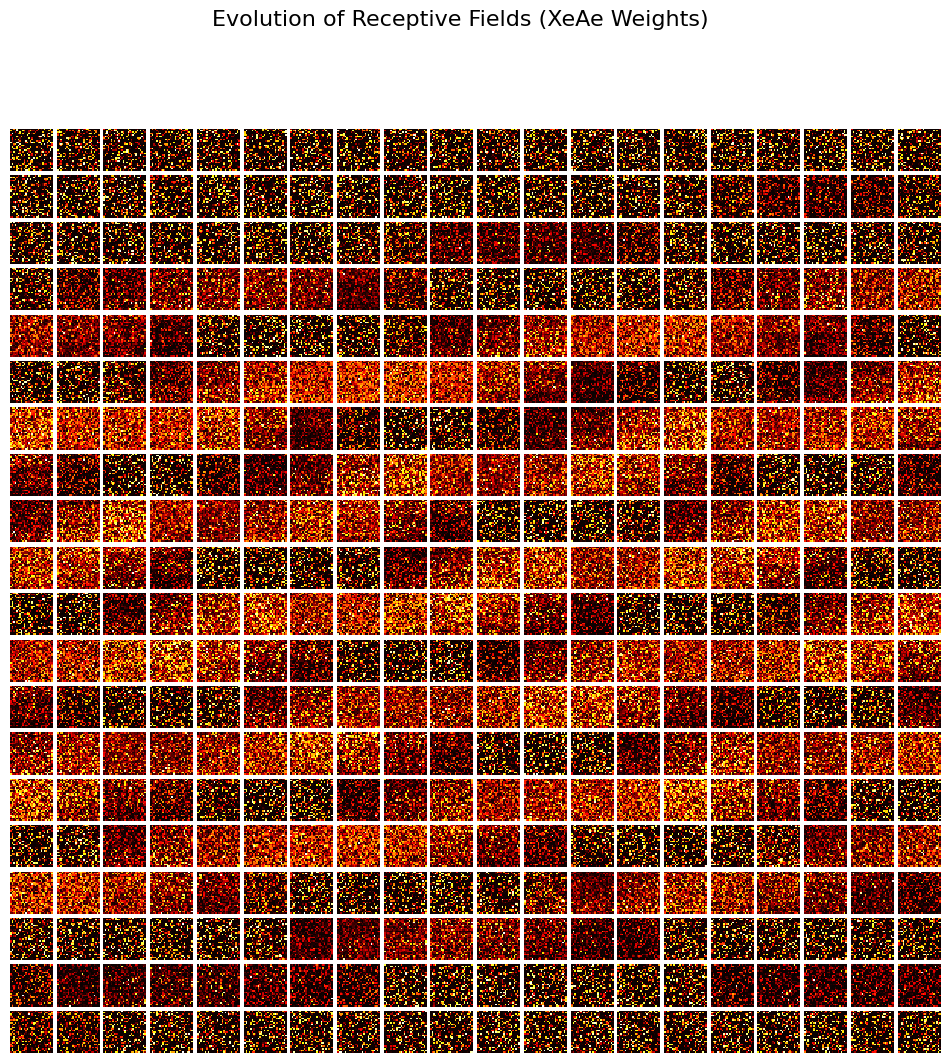

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the weights from the synapse object
# Brian2 stores weights in a flat array; we reshape to (N_neurons, 28, 28)
# We use .v to get the unitless values
current_weights = np.array(net['s_inp_exc'].w).reshape((n_e, 28, 28))
# 2. Setup the plotting grid (e.g., 20x20 for 400 neurons)
# If you have 400 neurons, a 20x20 grid shows them all
side = int(np.sqrt(n_e))
fig, axes = plt.subplots(side, side, figsize=(12, 12))
fig.suptitle('Evolution of Receptive Fields (XeAe Weights)', fontsize=16)

for i in range(side):
    for j in range(side):
        index = i * side + j
        ax = axes[i, j]
        
        # Display the weight matrix for neuron 'index'
        # 'hot' or 'viridis' are great colormaps for SNN weights
        img = ax.imshow(current_weights[index], cmap='hot', interpolation='nearest')
        ax.axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

In [20]:
import os
import numpy as np

# Create a directory for the trained model
save_path = './trained_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 1. Save the learned weights (XeAe)
# We pull the weights from the network using the name we gave the synapse
trained_weights = np.array(net['s_inp_exc'].w)
np.save(os.path.join(save_path, 'weights_1000.npy'), trained_weights)

# 2. Save the learned thresholds (theta)
# These are crucial for maintaining the neurons' firing preferences
trained_theta = np.array(net['exc'].theta)
np.save(os.path.join(save_path, 'theta_1000.npy'), trained_theta)

print(f"Model successfully saved to {save_path}")

Model successfully saved to ./trained_model/


--- Starting Batch 1/1 ---
Generating Spikes...


100%|███████████████████████████████████| 1000/1000 [00:18<00:00, 52.67it/s]


Sorting spikes chronologically...
Running Brian 2 simulation for 0.5 ks...
Starting simulation at t=0.9049622 ks for a duration of 0.5 ks
11.775 s (2%) simulated in 10s, estimated 6m 55s remaining.
23.4036 s (4%) simulated in 20s, estimated 6m 47s remaining.
34.8473 s (6%) simulated in 30s, estimated 6m 40s remaining.
46.3278 s (9%) simulated in 40s, estimated 6m 32s remaining.
58.3708 s (11%) simulated in 50s, estimated 6m 18s remaining.
70.2456 s (14%) simulated in 1m 0s, estimated 6m 7s remaining.
82.2847 s (16%) simulated in 1m 10s, estimated 5m 55s remaining.
94.3272 s (18%) simulated in 1m 20s, estimated 5m 44s remaining.
106.2822 s (21%) simulated in 1m 30s, estimated 5m 33s remaining.
118.2649 s (23%) simulated in 1m 40s, estimated 5m 23s remaining.
130.3087 s (26%) simulated in 1m 50s, estimated 5m 12s remaining.
142.2954 s (28%) simulated in 2m 0s, estimated 5m 2s remaining.
154.3195 s (30%) simulated in 2m 10s, estimated 4m 51s remaining.
166.4353 s (33%) simulated in 2m 20s

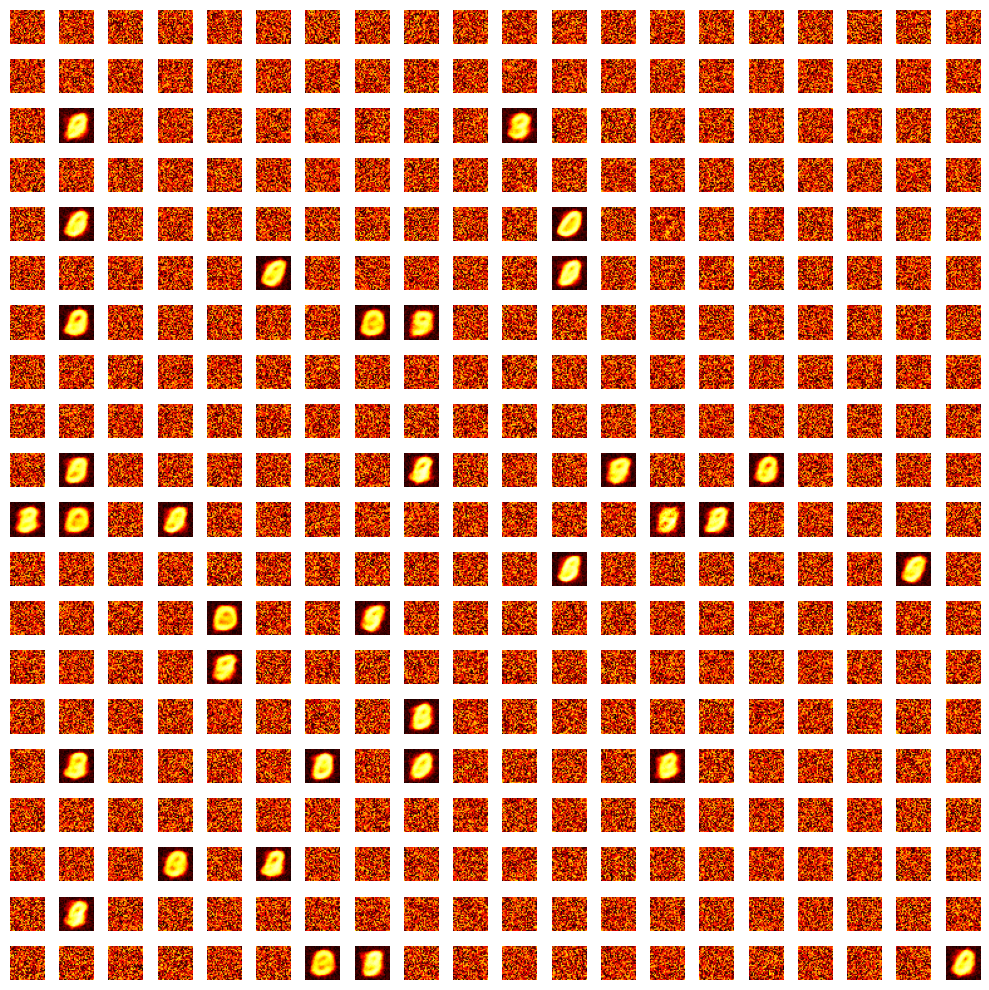

In [10]:
# import numpy as np
# from brian2 import *
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# # --- 1. Define Visualization Functions ---
# def get_2d_weights(synapse_group, n_input, n_e):
#     """Safely extracts Brian 2 1D weights into a 2D matrix using explicit indices."""
#     weight_matrix = np.zeros((n_input, n_e))
#     weight_matrix[synapse_group.i, synapse_group.j] = synapse_group.w
#     return weight_matrix

# def plot_weights(weights, n_e):
#     """Plots the weights as a grid of 28x28 images."""
#     fig, axes = plt.subplots(int(np.sqrt(n_e)), int(np.sqrt(n_e)), figsize=(10, 10))
#     wmax = np.max(weights) 
    
#     for i, ax in enumerate(axes.flat):
#         # vmin and vmax are crucial so background noise doesn't look bright
#         ax.imshow(weights[:, i].reshape(28, 28), cmap='hot', vmin=0, vmax=wmax)
#         ax.axis('off')
#     plt.tight_layout()
#     plt.show()

# # --- 2. Training Loop Parameters ---
# # Assuming 'net', 'X', 'n_input', 'n_e', 'E_rest', and 'I_rest' are already defined above
# batch_size = 1000 
# num_batches = 10
# time_per_image = 500.0  # e.g., 350ms active + 150ms resting phase
# target_weight = 78.0    # Magic number for Diehl & Cook MNIST normalization

# # --- 3. Run the Training ---
# for batch in range(num_batches):
#     print(f"--- Starting Batch {batch+1}/{num_batches} ---")
    
#     all_indices = []
#     all_times_ms = []
    
#     # Step A: Generate all spikes for the batch
#     print("Generating Spikes...")
#     for i in tqdm(range(batch_size)):
#         # Get the 1D image array (length 784)
#         current_image = X[batch * batch_size + i] 
        
#         # Generate spikes. 'spike_times' comes back with *ms units attached!
#         spike_indices, spike_times = generate_poisson_spikes(current_image, duration_ms=350.0)
#         image_start_offset_ms = i * time_per_image
        
#         # Strip the units by dividing by ms, add the offset, and store as plain floats
#         all_indices.extend(spike_indices)
#         all_times_ms.extend((spike_times / ms) + image_start_offset_ms)
        
#     # Step B: Convert to NumPy arrays and SORT chronologically
#     print("Sorting spikes chronologically...")
#     all_times_array = np.array(all_times_ms)
#     all_indices_array = np.array(all_indices)
    
#     sort_idx = np.argsort(all_times_array)
#     all_times_array = all_times_array[sort_idx]
#     all_indices_array = all_indices_array[sort_idx]
    
#     # Step C: Feed spikes to the network
#     # Re-apply the Brian unit (* ms) and add the current network time
#     net['inp'].set_spikes(all_indices_array, (all_times_array * ms) + net.t)
    
#     # Step D: Run the simulation
#     total_batch_time = batch_size * time_per_image * ms
#     print(f"Running Brian 2 simulation for {total_batch_time}...")
#     net.run(total_batch_time, report='text')
    
#     # Step E: Reset membrane voltages for the next batch
#     net['exc'].v = E_rest
#     net['inh'].v = I_rest
    
#     # Step F: Weight Normalization (Crucial for clear receptive fields)
#     print("Normalizing weights...")
#     W = get_2d_weights(net['s_inp_exc'], n_input, n_e)
    
#     # Sum the weights coming into each excitatory neuron
#     col_sums = np.sum(W, axis=0)
#     col_sums[col_sums == 0] = 1.0  # Prevent division by zero if a neuron is dead
    
#     # Scale all weights so each neuron's incoming connections sum to exactly target_weight
#     scale_factors = target_weight / col_sums
#     W = W * scale_factors[np.newaxis, :]
    
#     # Push the normalized weights back into the Brian 2 Synapses object
#     net['s_inp_exc'].w = W[net['s_inp_exc'].i, net['s_inp_exc'].j]

# # --- 4. Plot the final weights ---
# print("Visualizing learned Receptive Fields...")
# final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
# plot_weights(final_weights, n_e)

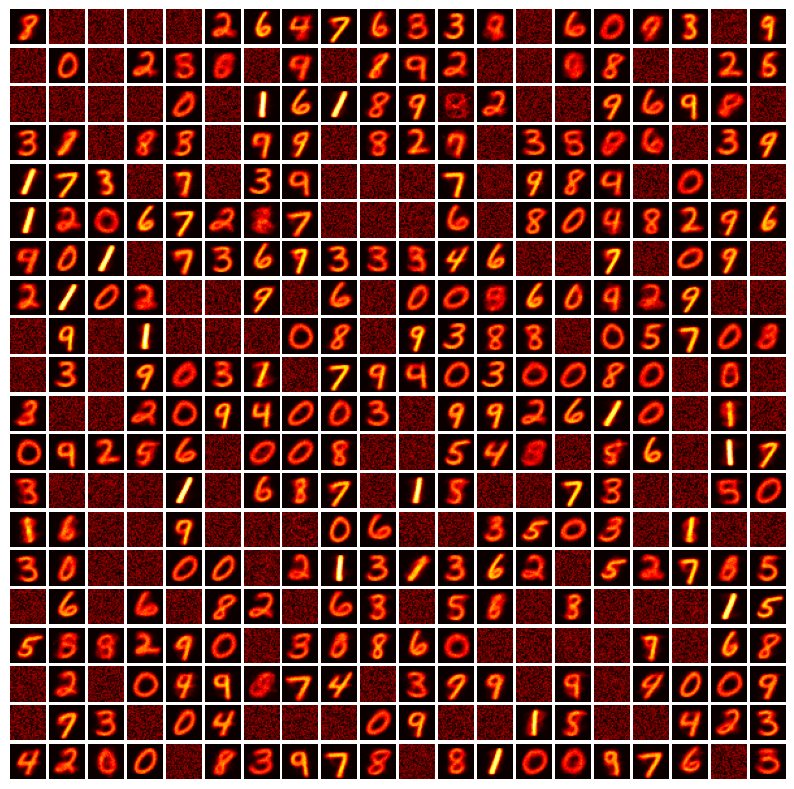

In [38]:
# --- 1. Define Visualization Functions ---
def get_2d_weights(synapse_group, n_input, n_e):
    """Safely extracts Brian 2 1D weights into a 2D matrix using explicit indices."""
    weight_matrix = np.zeros((n_input, n_e))
    weight_matrix[synapse_group.i, synapse_group.j] = synapse_group.w
    return weight_matrix

def plot_weights(weights, n_e):
    """Plots the weights as a grid of 28x28 images."""
    fig, axes = plt.subplots(int(np.sqrt(n_e)), int(np.sqrt(n_e)), figsize=(10, 10))
    wmax = np.max(weights) 
    
    for i, ax in enumerate(axes.flat):
        # vmin and vmax are crucial so background noise doesn't look bright
        ax.imshow(weights[:, i].reshape(28, 28), cmap='hot', vmin=0, vmax=wmax)
        ax.axis('off')
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()
    
final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
plot_weights(final_weights, n_e)

In [22]:
def build_network_test():
    # Input Layer
    inp_group = SpikeGeneratorGroup(n_input, indices=[], times=[]*ms, name='inp')

    # Excitatory Layer (Using eqs_e_test to freeze theta!)
    exc_group = NeuronGroup(n_e, eqs_e_test, threshold='v > v_thresh', reset='v = E_reset', 
                            refractory=E_refrac, method='euler', name='exc')
    
    # Inhibitory Layer
    inh_group = NeuronGroup(n_i, eqs_i, threshold='v > I_thresh', reset='v = I_reset', 
                            refractory=I_refrac, method='euler', name='inh')

    exc_group.v = E_rest
    inh_group.v = I_rest
    
    # Static Synapses: NO STDP! Just pass the weight forward.
    S_input_exc = Synapses(inp_group, exc_group, model='w : 1', on_pre='ge_post += w', name='s_inp_exc')
    S_input_exc.connect(p=1.0) # Fully connected

    # Inhibitory connections (Same as training)
    S_exc_inh = Synapses(exc_group, inh_group, on_pre='ge_post += w_ei', name='s_exc_inh')
    S_exc_inh.connect(j='i')

    S_inh_exc = Synapses(inh_group, exc_group, on_pre='gi_post += w_ie', name='s_inh_exc')
    S_inh_exc.connect(condition='i != j')

    # Spike monitor to see which neurons fire during the test
    spike_monitor = SpikeMonitor(exc_group, name='sp_exc')

    net = Network(inp_group, exc_group, inh_group, 
                  S_input_exc, S_exc_inh, S_inh_exc, 
                  spike_monitor)
    
    return net, spike_monitor, inp_group

In [28]:
import numpy as np
from brian2 import *
from tqdm import tqdm
# Ensure your constants, utils, and build_network_test are imported

def assign_neuron_labels(X_train_subset, y_train_subset, trained_weights_path, trained_theta_path):
    """
    Determines the preferred digit (0-9) for each excitatory neuron.
    """
    print("Initializing frozen network for label assignment...")
    prefs.codegen.target = 'cython'
    net, spike_monitor, inp_group = build_network_test()

    # Load the trained weights and thresholds
    print("Loading trained weights and thresholds...")
    net['s_inp_exc'].w = np.load(trained_weights_path)
    net['exc'].theta = np.load(trained_theta_path) * volt 

    num_examples = len(X_train_subset)
    duration = 250 * ms
    
    # Initialize a matrix to track spikes: [400 neurons x 10 classes]
    spike_rates = np.zeros((n_e, 10))
    
    # NEW: Keep a running tally of spikes so we don't have to delete the monitor
    previous_counts = np.zeros(n_e)
    
    print(f"Presenting {num_examples} images to determine labels...")
    
    for i in tqdm(range(num_examples)):
        current_image = X_train_subset[i]
        current_label = int(y_train_subset[i])
        
        # Generate spikes for the current image
        spike_indices, spike_times = generate_poisson_spikes(current_image, duration / ms)
        
        # Reset network state (voltages, conductances)
        net['exc'].v = E_rest
        net['inh'].v = I_rest
        net['exc'].ge = 0
        net['exc'].gi = 0
        
        # Inject spikes (Shifted forward by the current network time!)
        inp_group.set_spikes(spike_indices, spike_times + net.t)
        
        # Run the simulation
        net.run(duration)
        
        # --- NEW FAST SPIKE COUNTING ---
        # 1. Get the new total spike count array
        current_counts = np.array(spike_monitor.count)
        
        # 2. Subtract the previous total to get ONLY the spikes from this specific image
        spikes_this_image = current_counts - previous_counts
        
        # 3. Add these spikes to the corresponding class column
        spike_rates[:, current_label] += spikes_this_image
        
        # 4. Update the previous_counts tally for the next loop iteration
        previous_counts = current_counts.copy()

    # Determine the label for each neuron
    # np.argmax returns the index of the maximum value along the class axis
    neuron_labels = np.argmax(spike_rates, axis=1)
    
    return neuron_labels, spike_rates

# --- How to execute it ---

# 1. Use a subset of your training data (e.g., the first 5,000 images)
# Using all 60,000 takes a very long time and usually isn't necessary.
subset_size = 500
X_assign = X_train[:subset_size]
y_assign = y_train[:subset_size]

# 2. Run the assignment function
labels, rate_matrix = assign_neuron_labels(
    X_train_subset=X_assign, 
    y_train_subset=y_assign,
    trained_weights_path='./trained_model/weights_1000.npy',
    trained_theta_path='./trained_model/theta_1000.npy'
)

# 3. Save the labels so you can use them in your prediction script!
np.save('./trained_model/neuron_labels.npy', labels)

print("Label assignment complete!")
print("First 20 neuron labels:", labels[:20])

Initializing frozen network for label assignment...
Loading trained weights and thresholds...
Presenting 500 images to determine labels...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [04:53<00:00,  1.71it/s]

Label assignment complete!
First 20 neuron labels: [8 7 3 2 3 2 6 4 7 6 8 3 2 2 6 0 9 3 0 9]


In [30]:
import numpy as np
from brian2 import *
# Make sure to import your constants, generate_poisson_spikes, etc.

# 1. Initialize the TEST network
prefs.codegen.target = 'cython'
net, spike_monitor, inp_group = build_network_test()

# 2. Load your trained weights and thresholds
#print("Loading trained model...")
#net['s_inp_exc'].w = np.load('./trained_model/weights_1000.npy')
#net['exc'].theta = np.load('./trained_model/theta_1000.npy') * volt 

# 3. Create dummy neuron labels (CRITICAL STEP)
# Because it's unsupervised, you usually have to figure out which neuron maps to which digit.
# For this example, we assume you have an array mapping all 400 neurons to a digit (0-9).
# If you haven't calculated this yet, this array is just a placeholder!
# neuron_labels = np.random.randint(0, 10, size=n_e) 
neuron_labels = np.load("./trained_model/neuron_labels.npy") 

def predict_image(image_pixels):
    """
    Feeds a single image into the frozen SNN and returns the predicted digit.
    """
    duration = 350 * ms
    
    # Generate spikes for the test image
    spike_indices, spike_times = generate_poisson_spikes(image_pixels, duration / ms)
    
    # Reset network state (voltages, conductances) -- DO NOT touch net.t!
    net['exc'].v = E_rest
    net['inh'].v = I_rest
    net['exc'].ge = 0
    net['exc'].gi = 0
    
    # --- NEW FAST SPIKE COUNTING ---
    # Record the total spike count BEFORE we run the new image
    previous_counts = np.array(spike_monitor.count)
    
    # Inject spikes (Shifted forward by the current network time!)
    inp_group.set_spikes(spike_indices, spike_times + net.t)
    
    # Run the simulation for this image
    net.run(duration)
    
    # Record the total spike count AFTER the run
    current_counts = np.array(spike_monitor.count)
    
    # Subtract to find out how many spikes were caused by ONLY this image
    spikes_this_image = current_counts - previous_counts
    
    # --- Make the Prediction ---
    # Sum the spikes per class (0-9) based on our neuron_labels mapping
    class_scores = np.zeros(10)
    for neuron_idx, count in enumerate(spikes_this_image):
        label = neuron_labels[neuron_idx]
        class_scores[label] += count
        
    # The predicted digit is the class with the most total spikes
    predicted_digit = np.argmax(class_scores)
    
    return predicted_digit, class_scores
# --- Example Usage ---
# Assuming X_test contains your MNIST test images
test_image = X_test[2] 
actual_label = y_test[2]

prediction, scores = predict_image(test_image)

print(f"Actual Digit: {actual_label}")
print(f"SNN Predicted Digit: {prediction}")
print(f"Spike scores per class: {scores}")

WARNING    The object 'exc' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_81858/3337724942.py', line 6, in build_network_test
    exc_group = NeuronGroup(n_e, eqs_e_test, threshold='v > v_thresh', reset='v = E_reset', [brian2.core.base.unused_brian_object]
WARNING    The object 'inh' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_81858/3337724942.py', line 10, in build_network_test
    inh_group = NeuronGroup(n_i, eqs_i, threshold='v > I_thresh', reset='v = I_reset', [brian2.core.base.unused_brian_object]
WARNING    The object 's_inp_exc' is g

Actual Digit: 1
SNN Predicted Digit: 0
Spike scores per class: [270.  75. 174. 153.  51.  72. 120.  96.  81. 108.]


In [33]:
neuron_labels

array([8, 7, 3, 2, 3, 2, 6, 4, 7, 6, 8, 3, 2, 2, 6, 0, 9, 3, 0, 9, 3, 0,
       3, 2, 5, 0, 2, 9, 0, 8, 7, 2, 8, 6, 6, 8, 0, 3, 2, 6, 0, 0, 6, 3,
       0, 3, 0, 6, 1, 8, 9, 4, 2, 1, 7, 9, 6, 9, 8, 0, 3, 1, 0, 8, 3, 2,
       9, 9, 2, 8, 2, 7, 2, 3, 5, 7, 6, 6, 3, 9, 1, 7, 3, 6, 7, 0, 3, 0,
       2, 2, 2, 7, 0, 9, 8, 4, 9, 0, 6, 5, 1, 2, 0, 6, 7, 2, 2, 7, 2, 2,
       6, 6, 2, 8, 2, 4, 8, 0, 9, 6, 4, 0, 1, 2, 7, 3, 6, 7, 3, 3, 3, 4,
       6, 0, 3, 7, 1, 0, 9, 3, 2, 1, 0, 7, 2, 2, 9, 2, 6, 2, 0, 0, 5, 6,
       0, 9, 2, 9, 2, 2, 0, 9, 8, 1, 1, 4, 3, 0, 8, 2, 9, 3, 8, 0, 2, 0,
       5, 7, 0, 8, 0, 0, 2, 9, 0, 3, 1, 9, 7, 9, 4, 0, 3, 0, 0, 8, 0, 3,
       0, 0, 3, 6, 0, 2, 0, 9, 4, 0, 0, 3, 0, 9, 9, 2, 6, 1, 0, 8, 1, 2,
       0, 9, 2, 5, 6, 0, 0, 0, 5, 6, 4, 5, 4, 3, 0, 4, 6, 2, 1, 7, 3, 2,
       0, 2, 1, 2, 6, 8, 7, 0, 1, 5, 0, 0, 7, 3, 2, 3, 0, 0, 1, 6, 0, 3,
       9, 3, 7, 1, 0, 6, 6, 0, 5, 5, 0, 3, 0, 1, 0, 0, 3, 0, 3, 2, 0, 0,
       7, 2, 1, 3, 1, 3, 0, 2, 5, 5, 2, 7, 5, 5, 2,

In [34]:
import numpy as np
from tqdm import tqdm

def evaluate_model_accuracy(X_test_data, y_test_data, num_samples=1000):
    """
    Runs a subset of the test dataset through the SNN and calculates the accuracy.
    """
    print(f"Evaluating accuracy on {num_samples} test images...")
    
    correct_predictions = 0
    
    # Track guesses to see where the network gets confused
    # Rows = True Label, Columns = Predicted Label
    confusion_matrix = np.zeros((10, 10), dtype=int)
    
    for i in tqdm(range(num_samples)):
        test_image = X_test_data[i]
        true_label = int(y_test_data[i])
        
        # Use the predict_image function we optimized earlier
        predicted_digit, scores = predict_image(test_image)
        
        # Tally the results
        if predicted_digit == true_label:
            correct_predictions += 1
            
        # Log the prediction in our matrix
        confusion_matrix[true_label][predicted_digit] += 1
        
    # Calculate final percentage
    accuracy = (correct_predictions / num_samples) * 100.0
    
    print("\n" + "="*30)
    print("      EVALUATION COMPLETE      ")
    print("="*30)
    print(f"Total Correct: {correct_predictions} / {num_samples}")
    print(f"Overall Accuracy: {accuracy:.2f}%\n")
    
    print("Confusion Matrix (Rows=True, Cols=Predicted):")
    print(confusion_matrix)
    
    return accuracy, confusion_matrix

# --- How to execute it ---

# 1. Load your trained weights AND your trained thresholds
net['s_inp_exc'].w = np.load('./trained_model/weights_1000.npy')
net['exc'].theta = np.load('./trained_model/theta_1000.npy') * volt

# 2. Run the evaluation on the first 500 test images to test the waters
test_subset_size = 500 
final_accuracy, conf_matrix = evaluate_model_accuracy(X_test, y_test, num_samples=test_subset_size)

Evaluating accuracy on 500 test images...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [06:14<00:00,  1.33it/s]


      EVALUATION COMPLETE      
Total Correct: 328 / 500
Overall Accuracy: 65.60%

Confusion Matrix (Rows=True, Cols=Predicted):
[[38  0  0  0  1  2  0  1  0  0]
 [ 0 67  0  0  0  0  0  0  0  0]
 [ 2  3 36  3  4  2  1  2  2  0]
 [ 0  5  1 25  4  8  1  1  0  0]
 [ 0  1  3  0 37  4  0  0  0 10]
 [ 5  5  0  3  7 28  0  2  0  0]
 [ 6  1  6  0  4  2 23  0  1  0]
 [ 1  3  4  2  6  0  0 31  0  2]
 [ 0  1  5  3  8  6  0  1 15  1]
 [ 0  1  0  0 20  3  0  2  0 28]]


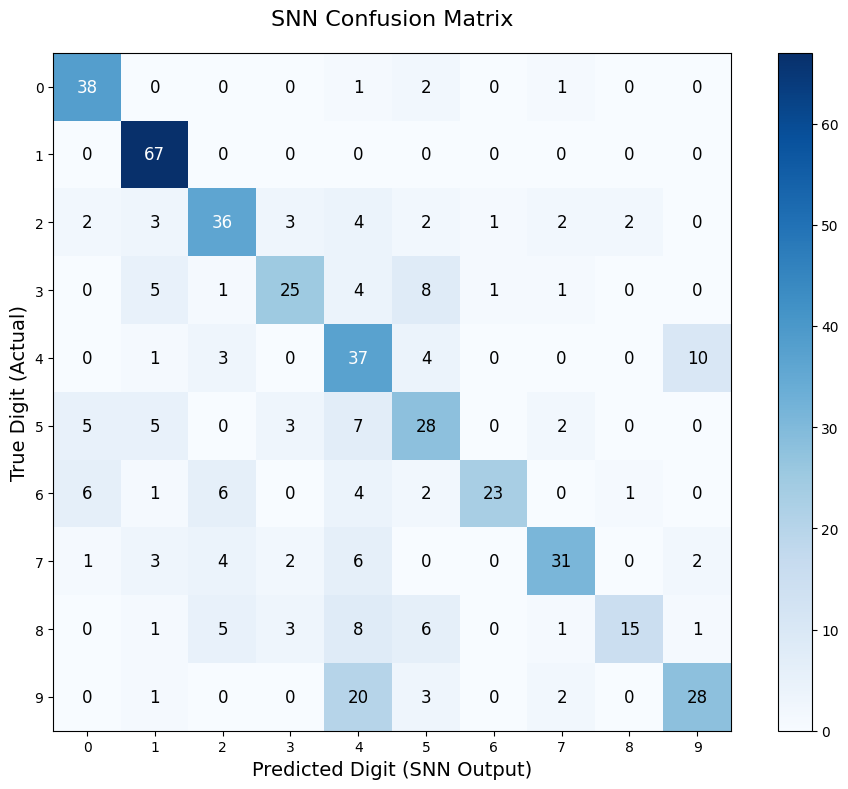

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm):
    """
    Plots a 10x10 confusion matrix using matplotlib.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create a heatmap
    # 'Blues' is a good colormap, but you can also use 'viridis' or 'hot'
    cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(cax)

    # Set up the axes labels (0 through 9)
    classes = np.arange(10)
    ax.set_xticks(classes)
    ax.set_yticks(classes)
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    
    # Add axis titles
    ax.set_ylabel('True Digit (Actual)', fontsize=14)
    ax.set_xlabel('Predicted Digit (SNN Output)', fontsize=14)
    ax.set_title('SNN Confusion Matrix', fontsize=16, pad=20)

    # Loop over the matrix data and add the raw numbers as text inside the boxes
    # We change the text color to white if the box background is very dark
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black",
                    fontsize=12)

    plt.tight_layout()
    plt.show()

# --- Run the Plot ---
# Pass the 'conf_matrix' variable that you generated in the previous evaluation step
plot_confusion_matrix(conf_matrix)